![](https://i.pinimg.com/originals/af/bf/af/afbfafac1e700ed3ed9b4a4157a7fa98.jpg)


# Soobi AI 高中體驗營🔸第三堂：手把手教你做AI


## 這堂課程要帶著大家利用最基礎、簡單的機器學習知識與演算法，完成Kaggle上鐵達尼號生存預測比賽，這次教學為了讓新手能夠快速上手，省去了許多較為複雜的統計知識與理論。

## 註：以正式比賽來說前10%就可以獲得一個銅牌成就，並可放在個人的履歷以及Linkedin上，對於想跨科系轉職資料科學家的人來說是一個大大加分的成就。
![](https://miro.medium.com/max/1400/1*IE87v8J_syODWQjyT6WB8Q.png)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os #os模塊提供了基本的文件和目錄操作，並且是跨平台的

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

In [ ]:
#Common Model Algorithms
from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier

#Common Model Helpers
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics

#Visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns
#from pandas.tools.plotting import scatter_matrix

#Configure Visualization Defaults
#%matplotlib inline = show plots in Jupyter Notebook browser
%matplotlib inline
mpl.style.use('ggplot')
sns.set_style('white')
pylab.rcParams['figure.figsize'] = 12,8

![](https://i.imgur.com/XO0VDDL.png)
# Step 1.瀏覽資料<BR>
# Step 2.整理資料<BR>
# Step 3.訓練模型<BR>
# Step 4.預測結果<BR>
# Step 5.產生檔案    

![](http://www.asparkstarts.com/wp-content/uploads/2015/01/start-button-300x240.jpg)

# Step 1.瀏覽資料

In [ ]:
train=pd.read_csv("../input/titanicdataset/Titanic_train.csv" )
tit1=train.select_dtypes(include=['float64','int64','object'])
train.info()

test=pd.read_csv("../input/titanicdataset/Titanic_test.csv")
tit2=test.select_dtypes(include=['float64','int64','object'])
test.info()

**We should know the data we are working with.**
* ID        乘客編號
* pclass    艙等1st, 2nd, or 3rd
* survived  Survived = 1;Died = 0
* name      乘客姓名
* sex       乘客性別
* age       年齡
* sibsp     旁系親屬人數
* parch     直系親屬人數
* ticket    船票編號
* fare      票價
* cabin     客艙編號
* embarked  登船港口;C = Cherbourg;Q = Queenstown;S = Southampton

In [ ]:
print("train shape:",train.shape)
tit1.head()
print("test shape :",test.shape)
tit2.head()

**Adding a column for Survived which has to be predicted in the test data.**

In [ ]:
tit2['survived']=np.nan
print("test shape :",tit2.shape)
tit2.head()

# **EXPLORING FEATURES**

**First we start by checking the counts of survived(1) and dead(0).
thus from the below graoh it is clear that there were more deaths than the ratio of survivors.
We also plot of graph for the division of genders, to see the ratio between men and women.
when the graph i splotted we see that the range of women seem more equivalent to the range of survivors and the range of deaths seem more closely related to the range of men.
So thus that mean that there were more women who survuived?
We shall se that further.**

In [ ]:
plt.figure(figsize=(4,4))
plt.title('survived',size=20)
tit1.survived.value_counts().plot.bar(color=['red','green'])

plt.figure(figsize=(4,4))
plt.title('sex',size=20)
tit1.sex.value_counts().plot.bar(color=['skyblue','pink'])

**Lets find out the Survival Rate and the percentage of Women and Men**

In [ ]:
percent=round(np.mean(train['survived']),3)*100
print("Percentage of Survivors:",percent,"%")
total=train['survived'].sum()
total
men=train[train['sex']=='male']
women=train[train['sex']=='female']
m=men['sex'].count()
w=women['sex'].count()
print("male:",m)
print("female:",w)
print("percentage of women:",round(w/(m+w)*100),"%")
print("percentage of men:",round(m/(m+w)*100),"%")

In [ ]:
plt.figure(figsize=(5,5))
plt.title("CLASS DIVISION",size=20)
tit1.pclass.value_counts().plot.bar(color=['olive','coral','gold'])

In [ ]:
train['fare'].hist(bins = 80, color = 'orange')
plt.title("FARE",size=20)

In [ ]:
plt.figure(figsize=(5,5))
plt.title("embarked",size=20)
tit1.embarked.value_counts().plot.bar(color=['olive','coral','gold'])

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'survived', hue = 'sex', data = train)
plt.title("SURVIVED AND SEX",size=20)

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'survived', hue = 'pclass', data = train)
plt.title("SURVIVED AND PCLASS",size=20)

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x = 'survived', hue = 'embarked', data = train)
plt.title("SURVIVED AND EMBARKED",size=20)

In [ ]:
#correlation heatmap of dataset
def correlation_heatmap(df):
    _ , ax = plt.subplots(figsize =(14, 12))
    colormap = sns.diverging_palette(220, 10, as_cmap = True)
    
    _ = sns.heatmap(
        df.corr(), 
        cmap = colormap,
        square=True, 
        cbar_kws={'shrink':.9 }, 
        ax=ax,
        annot=True, 
        linewidths=0.1,vmax=1.0, linecolor='white',
        annot_kws={'fontsize':12 }
    )
    
    plt.title('Pearson Correlation of Features', y=1.05, size=15)

correlation_heatmap(train)

# Step 2.整理資料<BR>
https://medium.com/jameslearningnote/%E8%B3%87%E6%96%99%E5%88%86%E6%9E%90-%E6%A9%9F%E5%99%A8%E5%AD%B8%E7%BF%92-%E7%AC%AC2-4%E8%AC%9B-%E8%B3%87%E6%96%99%E5%89%8D%E8%99%95%E7%90%86-missing-data-one-hot-encoding-feature-scaling-3b70a7839b4a <br>
    
**Lets check for the number of Null Values in our DATA SET**

In [ ]:
train.isnull().sum()

**AGE and CABIN have the higest number of Null Values,so they will not be of major help since most of the values are missing,especially CABIN.

依常識判斷，大膽假設票號與艙號與倖存機率不相關

In [ ]:
train = train.drop(['ticket', 'cabin'], axis=1)
test = test.drop(['ticket', 'cabin'], axis=1)

In [ ]:
train['age'].hist(bins=40,color='salmon')
plt.title("AGE",size=20)

**Calculating median values of "Age" by using "Pclass" to fill up the missing values.**

In [ ]:
age_group = train.groupby("pclass")["age"]
print(age_group.median())

In [ ]:
train.loc[train.age.isnull(),'age']=train.groupby("pclass").age.transform('median')
test.loc[test.age.isnull(),'age']=test.groupby("pclass").age.transform('median')
print(train['age'].isnull().sum())

In [ ]:
from statistics import mode
train["embarked"] = train["embarked"].fillna(mode(train["embarked"]))
test["embarked"] = test["embarked"].fillna(mode(test["embarked"]))
train["fare"] = train["fare"].fillna(mode(train["fare"]))

In [ ]:
print(train.isnull().sum())

In [ ]:
print(test.isnull().sum())

**So no more missing values in our dataset**

**Lets work out with the Cabin numbers**

**We will be searching for the initials of the cabin numbers like A,B,C,etc**

**Now we are assigning values to the initials that we had found in the above step and replace them with integers by mapping them.
Same step will be repeated for train and test data**

**Lets convert our categorical data to numeric form**

In [ ]:
train["sex"][train["sex"] == "male"] = 0
train["sex"][train["sex"] == "female"] = 1

test["sex"][test["sex"] == "male"] = 0
test["sex"][test["sex"] == "female"] = 1

train["embarked"][train["embarked"] == "S"] = 0
train["embarked"][train["embarked"] == "C"] = 1
train["embarked"][train["embarked"] == "Q"] = 2

test["embarked"][test["embarked"] == "S"] = 0
test["embarked"][test["embarked"] == "C"] = 1
test["embarked"][test["embarked"] == "Q"] = 2


**Lets create a new column of fam using SibSp which means number of Siblings or Spouse and Parch which means number of Parents or Children,later we will be dropping SibSp and Parch from our data set since these values are alreday being used in Fam**

In [ ]:
train['fam']=train['sibsp']+train['parch']+1
test['fam']=test['sibsp']+test['parch']+1

In [ ]:
train['isAlone'] = 0
train.loc[train['fam'] == 1, 'isAlone'] = 1
test['isAlone'] = 0
test.loc[test['fam'] == 1, 'isAlone'] = 1

**Lets play a little with Age as well**

**First we are converting float to string for both the datasets namely test and train**

In [ ]:
train['age']=train['age'].astype(str)
test['age']=test['age'].astype(str)

**Now we will do the same thing that we did with cabin so that we are left with the initials and can assign them numeric values accordingly.**

In [ ]:
import re
train['age'] = train['age'].map(lambda x: re.compile("[0-9]").search(x).group())
train['age'].unique().tolist()

In [ ]:
#cat={'2':1, '3':2 , '5':3, '1':4 ,'4':5,'8':6,'6':7,'7':8,'0':9,'9':10}
cat={'0':1,'1':2 ,'2':3, '3':3 , '4':5,'5':6, '6':7,'7':8,'8':9,'9':10}
train['age']=train['age'].map(cat)
train['age'].unique().tolist()

In [ ]:
test['age'] = test['age'].map(lambda x: re.compile("[0-9]").search(x).group())
test['age'].unique().tolist()

**Mapping values**

In [ ]:
test['age']=test['age'].map(cat)
test['age'].unique().tolist()

**Lets play around with Name as well!**

新增Title欄位

In [ ]:
train['title'] = train.name.str.extract(' ([A-Za-z]+)\.', expand=False)
train['title'] = train['title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train['title'] = train['title'].replace('Mlle', 'Miss')
train['title'] = train['title'].replace('Ms', 'Miss')
train['title'] = train['title'].replace('Mme', 'Mrs')
    
train[['title', 'survived']].groupby(['title'], as_index=False).mean()

In [ ]:
test['title'] = test.name.str.extract(' ([A-Za-z]+)\.', expand=False)
test['title'] = test['title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
test['title'] = test['title'].replace('Mlle', 'Miss')
test['title'] = test['title'].replace('Ms', 'Miss')
test['title'] = test['title'].replace('Mme', 'Mrs')


In [ ]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train['title'] = train['title'].map(title_mapping)
train['title'] = train['title'].fillna(0)
test['title'] = test['title'].map(title_mapping)
test['title'] = test['title'].fillna(0)
train.head()

In [ ]:
train = train.drop(['name'], axis = 1)
train = train.drop(['parch'], axis = 1)
train = train.drop(['fare','sibsp'], axis = 1)
#train = train.drop(['fam'], axis = 1)
test = test.drop(['name'], axis = 1)
test = test.drop(['parch'], axis = 1)
test = test.drop(['fare','sibsp'], axis = 1)
#test = test.drop(['fam'], axis = 1)

In [ ]:
train.head()


In [ ]:
test.head()

In [ ]:
#train = pd.get_dummies(train)
#pd.DataFrame(train)


In [ ]:
#test = pd.get_dummies(test)
#pd.DataFrame(test)

In [ ]:
print(train)
print(test)

# Step 3.訓練模型<BR>
**Lets start predicting,we will be using Logistic Regression.Logistic Regression is the appropriate regression analysis to conduct when the dependent variable is dichotomous (binary).  Like all regression analyses, the logistic regression is a predictive analysis.  Logistic regression is used to describe data and to explain the relationship between one dependent binary variable and one or more nominal, ordinal, interval or ratio-level independent variables.**

**train_test_split :Split arrays or matrices into random train and test subsets**

train_test_split功能是從樣本中隨機的按比例選取train_data和test_data，使用方式為：
X_train,X_test, y_train, y_test =cross_validation.train_test_split(train_data,train_target,test_size=0.4, random_state=0)

引數解釋：
train_data：所要劃分的樣本特徵集
train_target：所要劃分的樣本結果
test_size：樣本佔比，如果是整數的話就是樣本的數量
random_state：是隨機數的種子。

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(train.drop(['survived','ID'], axis=1), 
                                                    train['survived'], test_size = 0.2, 
                                                    random_state = 42)

# **LOGISTIC REGRESSION**
參考來源 http://www.taroballz.com/2018/07/18/ML_LogisticRegression/


In [ ]:
from sklearn.linear_model import LogisticRegression
logisticRegression = LogisticRegression()
logisticRegression.fit(X_train, y_train)

**Making and Printing our predictions**

In [ ]:
predictions = logisticRegression.predict(X_test)
acc_LOG = round(accuracy_score(predictions, y_test) * 100, 2)
print(acc_LOG)
print(predictions)

# Step 4.預測結果<BR>

**Lets take help of confusion matrix to find out TP TN FP FN.A confusion matrix is a summary of prediction results on a classification problem. The number of correct and incorrect predictions are summarized with count values and broken down by each class. This is the key to the confusion matrix. The confusion matrix shows the ways in which your classification model is confused when it makes predictions. It gives us insight not only into the errors being made by a classifier but more importantly the types of errors that are being made.
**


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

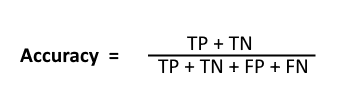


![](https://i.imgur.com/GwlR2n4.jpg)

In [ ]:
accuracy=((tp+tn)/(tp+tn+fp+fn))
print('accuracy is: ', (round(accuracy, 2)*100),'%')

# Step 5.產生檔案<BR>
**SUBMISSION FILE(choosing Gradient Boosting)**

In [ ]:
ids = test['ID']
#predictions = randomforest.predict(test.drop('ID', axis=1))
predictions = logisticRegression.predict(test.drop('ID', axis=1))

output = pd.DataFrame({ 'ID' : ids, 'survived': predictions })
output.to_csv('submission.csv', index=False)

# 上傳作業，看看自己的成績如何?
# https://www.kaggle.com/t/fc5bcffb8a7f4734b1fb6f58b1883947

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0)

clf.fit(X_train, y_train)

In [ ]:
ids = test['ID']
#predictions = randomforest.predict(test.drop('ID', axis=1))
predictions = clf.predict(test.drop('ID', axis=1))

output = pd.DataFrame({ 'ID' : ids, 'survived': predictions })
output.to_csv('submission_clf.csv', index=False)

In [ ]:
from sklearn.svm import SVC, LinearSVC

svc = SVC()
svc.fit(X_train, y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, y_train) * 100, 2)
print(acc_svc)

ids = test['ID']
#predictions = randomforest.predict(test.drop('ID', axis=1))
predictions = svc.predict(test.drop('ID', axis=1))

output = pd.DataFrame({ 'ID' : ids, 'survived': predictions })
output.to_csv('submission_svc.csv', index=False)

In [ ]:
ids = test['ID']
#predictions = randomforest.predict(test.drop('ID', axis=1))
predictions = svc.predict(test.drop('ID', axis=1))

output = pd.DataFrame({ 'ID' : ids, 'survived': predictions })
output.to_csv('submission_svc.csv', index=False)